# Ternary Activation with Dual Sampling approach


In [1]:
import argparse
import csv
import fcntl
import jax
import math
import jax.numpy as jnp
import optax
import flax
from flax import nnx
from flax.nnx.nn import initializers
from typing import Callable
import json
import os
import pickle
import numpy as np
from collections import defaultdict
from functools import partial
from tqdm import tqdm
from datetime import date

import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns



from utils import ternary_activation, load_cifar10_augment
from models import TernaryStochasticActivation

import tensorflow_datasets as tfds  # TFDS to download CIFAR-10.
import tensorflow as tf  # TensorFlow / `tf.data` operations.

today = date.today().isoformat()

In [2]:
## defining the activation function
@jax.custom_vjp
def dual_sample_ternary(
        x: float,
        key: jax.random.key,
        threshold: float = 0.0,
        noise_std: float = 1.0,
        noise_mean: float = 0.0,
    ):

    # generate independent noise samples
    key1, key2, subkey = jax.random.split(key, 3)
    noise1 = jax.random.normal(key1)*noise_std + noise_mean
    noise2 = jax.random.normal(key2)*noise_std + noise_mean

    # perturb the inputs with noise
    s1 = x + noise1
    s2 = x + noise2

    # find the threshold crossing for both samples
    s1 = s1 > threshold
    s2 = s2 > threshold

    # determine the sign
    sign = jnp.where(
        jnp.logical_and(s1, s2), 1.0,
        jnp.where(
            jnp.logical_and(jnp.logical_not(s1), jnp.logical_not(s2)), -1.0,
            0.0
        )
    )

    # determine the output magnitude
    mag = jnp.logical_not(jnp.logical_xor(s1, s2)).astype(jnp.float32)

    return sign * mag

def dual_sample_ternary_fwd(
    x: float,
    key: jax.random.key,
    threshold: float = 0.0,
    noise_std: float = 1.0,
    noise_mean: float = 0.0,
    **kwargs
):
    y = dual_sample_ternary(
        x,
        key,
        threshold=threshold,
        noise_std=noise_std,
        noise_mean=noise_mean,
        **kwargs
    )
    return y, (y, x, key, threshold, noise_std, noise_mean)

def dual_sample_ternary_bwd(residuals, gradients):
    y, x, key, threshold, noise_std, noise_mean = residuals

    dx = gradients * (1 - jnp.square(y)) # gradient is 1 when output is 1 or -1, else 0

    return (dx, None, None, None, None)

# bind the forward and backward functions
dual_sample_ternary.defvjp(dual_sample_ternary_fwd, dual_sample_ternary_bwd)

    

# defining the expected state
def expected_state(
        x: float,
        threshold: float = 0.0,
        noise_std: float = 1.0,
        noise_mean: float = 0.0,
        **kwargs
    ):

    p = jax.scipy.stats.norm.cdf(x=threshold, loc=x, scale=noise_std)

    return 1 - 2*p


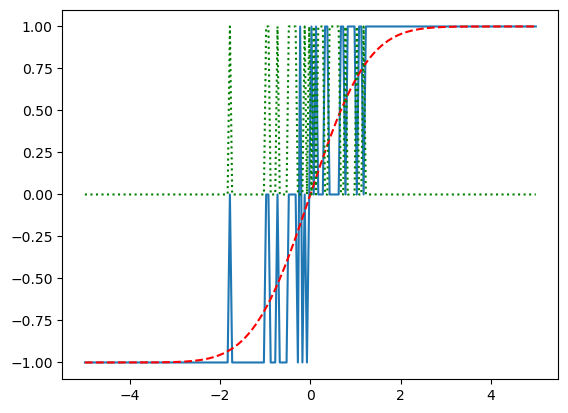

In [5]:
# plotting the activation
std = 1
x_arr = jnp.linspace(-5., 5., 200)
keys = jax.random.key(0)
keys = jax.random.split(keys, x_arr.shape[0])
y_arr = jax.vmap(dual_sample_ternary, in_axes=(0, 0, None, None, None))(x_arr, keys, 0.0, std, 0.0)
exp_state = jax.vmap(expected_state, in_axes=(0, None, None, None))(x_arr, 0.0, std, 0.0)

grad_fn = jax.grad(dual_sample_ternary, argnums=0)
grads = jax.vmap(grad_fn, in_axes=(0, 0, None, None, None))(x_arr, keys, 0.0, std, 0.0)

fig, ax = plt.subplots()
ax.plot(x_arr, y_arr)
ax.plot(x_arr, exp_state, color='red', linestyle='dashed')
ax.plot(x_arr, grads, color='green', linestyle='dotted')